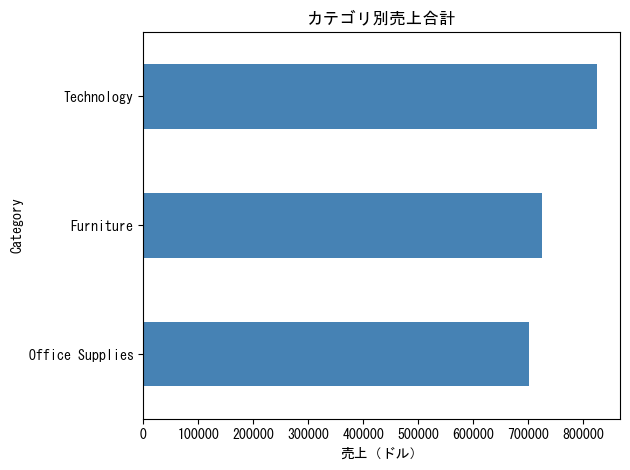

In [3]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'MS Gothic'

df = pd.read_csv('sales_analysis.csv')
df = df.drop(columns=['Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20'])
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

category_sales = df.groupby('Category')['Sales'].sum().sort_values()

category_sales.plot(kind='barh', color='steelblue')
plt.title('カテゴリ別売上合計')
plt.xlabel('売上（ドル）')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

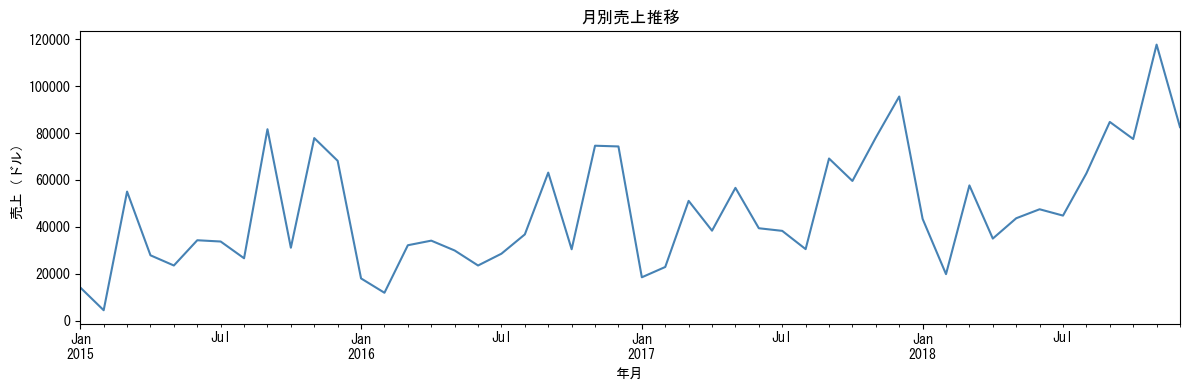

In [4]:
# 月別売上推移
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

monthly_sales.plot(figsize=(12, 4), color='steelblue')
plt.title('月別売上推移')
plt.xlabel('年月')
plt.ylabel('売上（ドル）')
plt.tight_layout()
plt.savefig('monthly_sales.png')
plt.show()

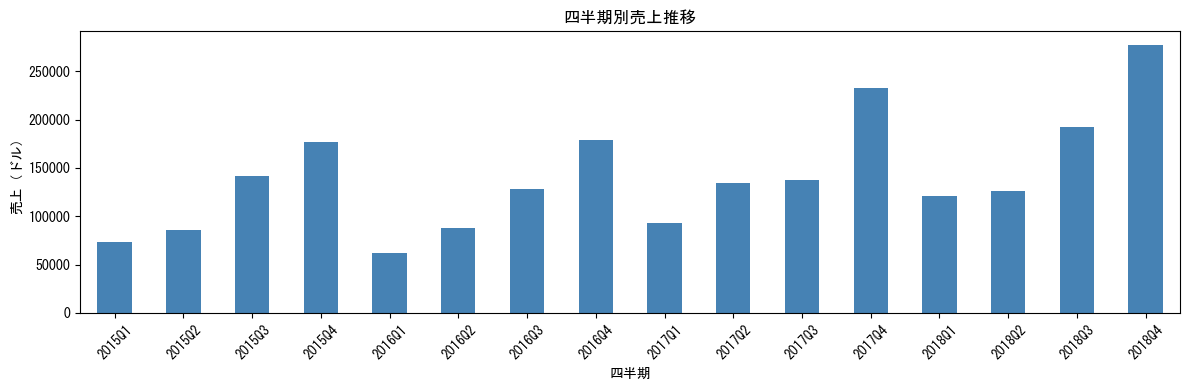

In [5]:
# 四半期別売上推移
df['Quarter'] = df['Order Date'].dt.to_period('Q')
quarterly_sales = df.groupby('Quarter')['Sales'].sum()

quarterly_sales.plot(kind='bar', figsize=(12, 4), color='steelblue')
plt.title('四半期別売上推移')
plt.xlabel('四半期')
plt.ylabel('売上（ドル）')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('quarterly_sales.png')
plt.show()

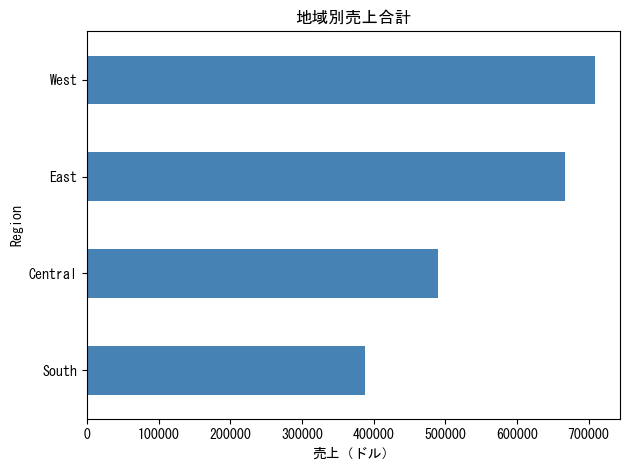

In [6]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='barh', color='steelblue')
plt.title('地域別売上合計')
plt.xlabel('売上（ドル）')
plt.tight_layout()
plt.savefig('region_sales.png')
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 月別売上データを数値化
monthly_sales_reset = monthly_sales.reset_index()
monthly_sales_reset['month_num'] = range(len(monthly_sales_reset))

X = monthly_sales_reset[['month_num']]
y = monthly_sales_reset['Sales']

model = LinearRegression()
model.fit(X, y)

print(f'月ごとの売上増加トレンド：{model.coef_[0]:.0f}ドル/月')

月ごとの売上増加トレンド：880ドル/月


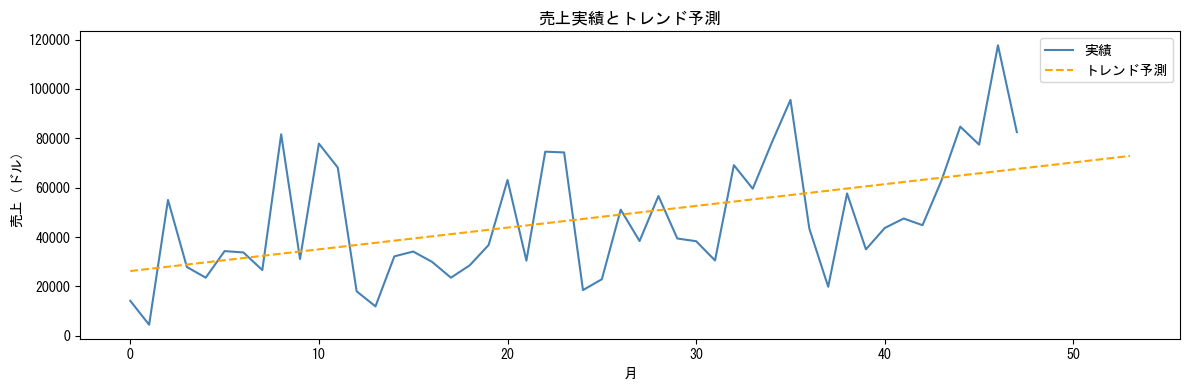

In [8]:
# 予測グラフ
plt.figure(figsize=(12, 4))

# 実績値
plt.plot(monthly_sales.values, label='実績', color='steelblue')

# 予測値（全期間＋未来6ヶ月）
future_months = pd.DataFrame(
    range(len(monthly_sales) + 6), 
    columns=['month_num']
)
predicted = model.predict(future_months)
plt.plot(predicted, label='トレンド予測', color='orange', linestyle='--')

plt.title('売上実績とトレンド予測')
plt.xlabel('月')
plt.ylabel('売上（ドル）')
plt.legend()
plt.tight_layout()
plt.savefig('sales_prediction.png')
plt.show()

18:50:19 - cmdstanpy - INFO - Chain [1] start processing
18:50:20 - cmdstanpy - INFO - Chain [1] done processing


MAE（平均絶対誤差）: 5868ドル
RMSE（二乗平均平方根誤差）: 7476ドル


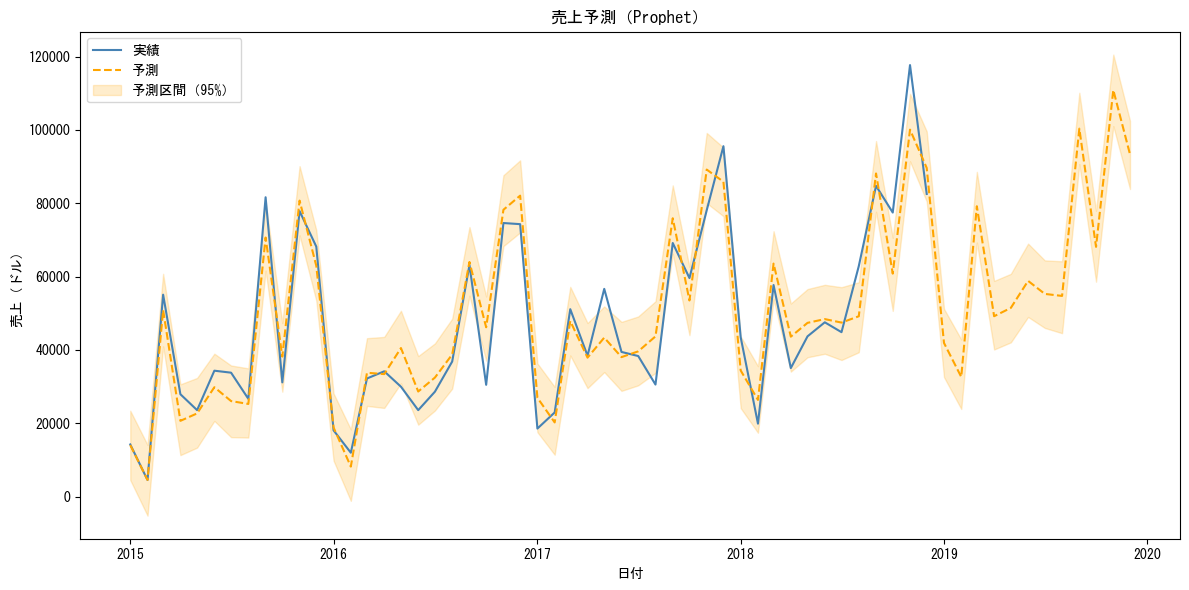

In [9]:
!pip install prophet

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'MS Gothic'

# Prophetが要求する形式に変換（ds=日付, y=売上）
df_prophet = monthly_sales.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = df_prophet['ds'].dt.to_timestamp()

# モデル構築・学習
model = Prophet(
    yearly_seasonality=True,   # 年次季節性（年末の繁忙期など）を考慮
    weekly_seasonality=False,  # 月次データなので週次は不要
    daily_seasonality=False    # 月次データなので日次も不要
)
model.fit(df_prophet)

# 12ヶ月先まで予測
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# 予測精度を計算（実績データ部分のみ）
from sklearn.metrics import mean_absolute_error, mean_squared_error
actual = df_prophet['y'].values
predicted = forecast['yhat'][:len(actual)].values
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
print(f'MAE（平均絶対誤差）: {mae:.0f}ドル')
print(f'RMSE（二乗平均平方根誤差）: {rmse:.0f}ドル')

# 可視化
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_prophet['ds'], df_prophet['y'], label='実績', color='steelblue')
ax.plot(forecast['ds'], forecast['yhat'], label='予測', color='orange', linestyle='--')
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'],
                forecast['yhat_upper'],
                alpha=0.2, color='orange', label='予測区間（95%）')
ax.set_title('売上予測（Prophet）')
ax.set_xlabel('日付')
ax.set_ylabel('売上（ドル）')
ax.legend()
plt.tight_layout()
plt.savefig('sales_prediction_prophet.png')
plt.show()

In [10]:
print(f"月別売上の平均: {monthly_sales.mean():.0f}ドル")
print(f"月別売上の標準偏差: {monthly_sales.std():.0f}ドル")
print(f"月別売上の最小: {monthly_sales.min():.0f}ドル")
print(f"月別売上の最大: {monthly_sales.max():.0f}ドル")
print(f"MAPE（平均絶対誤差率）: {(5868 / monthly_sales.mean() * 100):.1f}%")

月別売上の平均: 46918ドル
月別売上の標準偏差: 24864ドル
月別売上の最小: 4504ドル
月別売上の最大: 117667ドル
MAPE（平均絶対誤差率）: 12.5%
